In [1]:
import os, glob, re
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Load in the Turbines location

In [20]:
# Simple hub regex -> throw out rows that aren’t actual turbines
_HUB_REGEX = re.compile(
    r"(?:^|\b)(?:OSS|OHVS|SUB-?STATION|OFFSHORE\s+HIGH\s+VOLTAGE|HUB|PLATFORM)(?:\b|$)",
    flags=re.IGNORECASE
)

def load_turbines(dir_path="coordinates"):
    """Load all *turbines_coords.csv, drop hub rows, return df with farm, lon, lat."""
    rows = []
    for csv in glob.glob(os.path.join(dir_path, "*_turbines_coords.csv")):
        farm = os.path.basename(csv).replace("_turbines_coords.csv", "")
        df = pd.read_csv(csv)
        cols = {c.lower().strip(): c for c in df.columns}
        name_col = cols.get("name", "NAME")
        lon_col  = cols.get("longitude", "LONGITUDE")
        lat_col  = cols.get("latitude", "LATITUDE")
        sub = df[[name_col, lon_col, lat_col]].copy()
        sub.columns = ["name","lon","lat"]
        # Drop hubs
        mask = ~sub["name"].astype(str).str.contains(_HUB_REGEX)
        sub = sub.loc[mask]
        sub["farm"] = farm
        rows.append(sub[["farm","lon","lat"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["farm","lon","lat"])
turbines=load_turbines()

In [21]:
#a helper function to plot the cerra grid
def add_cerra_cells(ax, ds, linewidth=0.4, color="red"):
    lon2d = ds["longitude"].values
    lat2d = ds["latitude"].values
    qm = ax.pcolormesh(
        lon2d, lat2d, np.zeros_like(lon2d),
        shading="nearest", transform=ccrs.PlateCarree(),
        edgecolors=color, alpha=0.2, linewidth=linewidth
    )
    qm.set_facecolor("none")
    return qm

### Make plots 

In [50]:
def plot_cerra_map(
    ds,
    extent=(-12, 12, 48, 59),
    show_turbines=True,
    turbines=turbines,
    label_farms=True,
    grid_color="red",
    grid_linewidth=0.4,
    coast_res="10m",
    show_grid_outline=False,
    Cities=False,
    legend=True
):
    fig, ax = plt.subplots(figsize=(8.5, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution=coast_res)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linestyle=":", linewidth=0.5, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

    countries = cfeature.NaturalEarthFeature("cultural", "admin_0_countries", scale="10m", facecolor="none")
    ax.add_feature(countries, edgecolor="gray", linewidth=0.5)

    add_cerra_cells(ax, ds, linewidth=grid_linewidth, color=grid_color)

    if show_turbines:
        tdf = turbines
        farms = sorted(tdf["farm"].unique())
        cmap = plt.get_cmap("tab20")
        colors = {farm: cmap(i % 20) for i, farm in enumerate(farms)}
        handles = []
        for farm in farms:
            sub = tdf[tdf["farm"] == farm]
            sc = ax.scatter(
                    sub["lon"], sub["lat"],
                    s=18, marker="o", edgecolors="k", facecolors=colors[farm],
                    linewidths=0.4, transform=ccrs.PlateCarree(), zorder=5, label=farm
                )
            handles.append(sc)
            if label_farms:
                ax.text(
                        float(sub["lon"].median()) + 0.015,
                        float(sub["lat"].median()) + 0.01,
                        farm, transform=ccrs.PlateCarree(), fontsize=8, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6),
                        zorder=6
                    )
            if legend:
                ax.legend(handles=handles, loc="lower left", fontsize=12, frameon=True)

    #add Bruges and Ghent
    if Cities:
        ax.plot(3.224167, 51.208889, "ro", markersize=6)
        ax.text(3.224167, 51.208889+0.05, "Bruges", fontsize=9, color="black")
        ax.plot(3.725278, 51.053611, "ro", markersize=6)
        ax.text(3.725278, 51.053611+0.05, "Ghent", fontsize=9, color="black")
    
    ax.set_title("CERRA Grid with Wind Turbines")
    plt.tight_layout()
    plt.savefig("zoomout_withoutlabels.png")
    plt.show()

### Some plots

In [51]:
ds=xr.open_dataset("/mnt/data/weatherloss/WindPower/data/cerra_boz/nc_boz/cerra_pressure_2024_01_BOZ.nc")

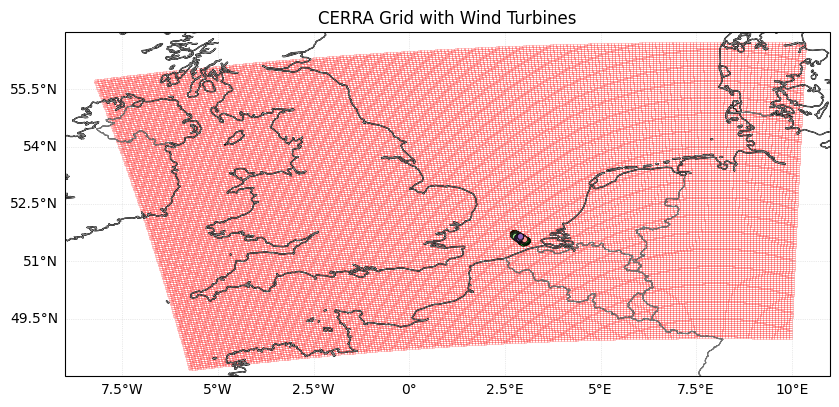

In [52]:
plot_cerra_map(ds,extent=(-9, 11, 48, 57), show_turbines=True,label_farms=False,legend=False,Cities=False)

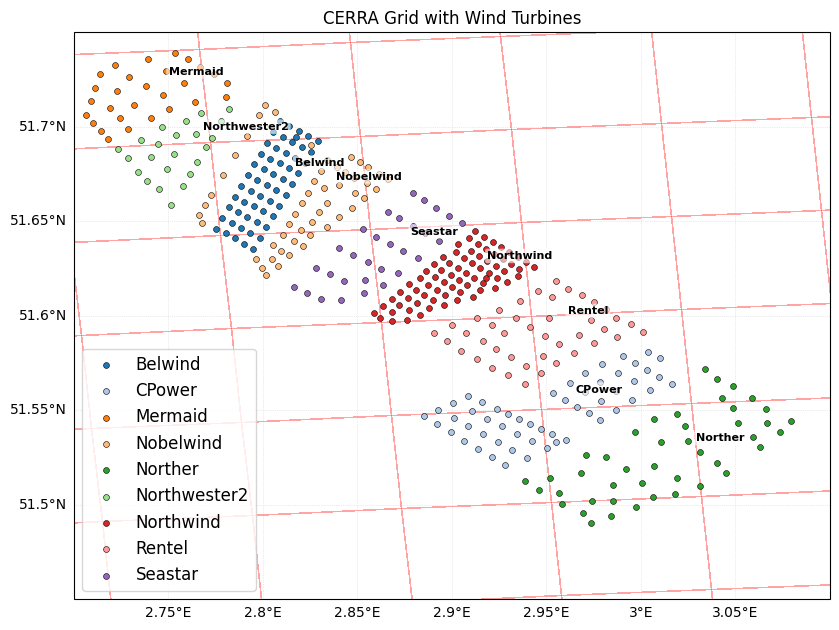

In [25]:
plot_cerra_map(ds, extent=(2.7,3.1,51.45,51.75))